# T14 — Final Summary & Model Comparison

This notebook loads `results/all_model_results.csv` (written by every model notebook) and produces:
1. Full ranked comparison table (all models)
2. Grouped bar chart — RMSE + NASA score by model family
3. Quantile model calibration summary (coverage + interval width)
4. Literature benchmark comparison
5. Key findings summary


## 1. Imports & Setup

In [18]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root
from src.evaluation.metrics import (
    load_all_results, plot_model_comparison, compare_to_benchmarks,
)
from src.utils.config import RESULTS_DIR as RESULTS
import pandas as pd, numpy as np, matplotlib.pyplot as plt


## 2. Load & Display All Model Results

In [19]:
df = load_all_results()

if df.empty:
    print('WARNING: results/all_model_results.csv is empty or missing.')
    print('Run all model notebooks first (T08, T09, T10, MLP, RNN, LSTM, GRU, Transformer, Q-*).')
else:
    print(f'Loaded {len(df)} model results')
    print(f'Model types: {df["model_type"].value_counts().to_dict()}')
    print()
    display_cols = ['model_name', 'model_type', 'rmse', 'nasa_score', 'r2_score', 'bias',
                    'interval_width', 'coverage_pct', 'n_test_engines', 'timestamp']
    display_cols = [c for c in display_cols if c in df.columns]
    pd.set_option('display.float_format', '{:.3f}'.format)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 140)
    print(df[display_cols].to_string(index=False))

Loaded 27 model results
Model types: {'quantile': 15, 'classical': 7, 'dl': 5}

         model_name model_type   rmse  nasa_score  r2_score   bias  interval_width  coverage_pct  n_test_engines           timestamp
        Transformer         dl 14.422    1093.540     0.887 -1.273             NaN           NaN             248 2026-05-05 18:09:50
Q_Transformer+cal90   quantile 14.934    1897.570     0.879  1.089          33.163        90.730             248 2026-05-05 17:54:00
Q_Transformer+cal80   quantile 14.934    1897.570     0.879  1.089          20.863        80.650             248 2026-05-05 17:54:00
      Q_Transformer   quantile 14.935    1897.660     0.879  1.089          16.602        68.550             248 2026-05-05 17:37:30
        Q_GRU+cal90   quantile 15.225    1679.670     0.875  4.640          35.636        90.730             248 2026-05-05 17:54:00
        Q_GRU+cal80   quantile 15.225    1679.670     0.875  4.640          25.078        80.650             248 2026-05-0

In [20]:
# Styled table for notebooks
if not df.empty:
    styled = (df[display_cols]
              .style
              .background_gradient(subset=['rmse'], cmap='RdYlGn_r')
              .background_gradient(subset=['r2_score'], cmap='RdYlGn')
              .format({
                  'rmse': '{:.3f}', 'nasa_score': '{:.1f}', 'nasa_score_mean': '{:.3f}',
                  'r2_score': '{:.4f}', 'bias': '{:.3f}',
                  'interval_width': '{:.2f}', 'coverage_pct': '{:.1f}',
              }, na_rep='—')
              .set_caption('All Model Results — ranked by RMSE (lower is better)'))
    display(styled)

,model_name,model_type,rmse,nasa_score,r2_score,bias,interval_width,coverage_pct,n_test_engines,timestamp
rank,,,,,,,,,,
1,Transformer,dl,14.422,1093.5,0.8874,-1.273,—,—,248,2026-05-05 18:09:50
2,Q_Transformer+cal90,quantile,14.934,1897.6,0.8793,1.089,33.16,90.7,248,2026-05-05 17:54:00
3,Q_Transformer+cal80,quantile,14.934,1897.6,0.8793,1.089,20.86,80.7,248,2026-05-05 17:54:00
4,Q_Transformer,quantile,14.935,1897.7,0.8793,1.089,16.60,68.5,248,2026-05-05 17:37:30
5,Q_GRU+cal90,quantile,15.225,1679.7,0.8745,4.640,35.64,90.7,248,2026-05-05 17:54:00
6,Q_GRU+cal80,quantile,15.225,1679.7,0.8745,4.640,25.08,80.7,248,2026-05-05 17:54:00
7,Q_GRU,quantile,15.226,1679.6,0.8745,4.640,19.97,71.8,248,2026-05-05 17:41:11
8,GRU,dl,15.291,1389.3,0.8734,0.710,—,—,248,2026-05-05 18:20:58
9,RNN,dl,15.669,978.5,0.8671,-3.499,—,—,248,2026-05-05 18:20:31


## 3. Model Comparison — Bar Charts

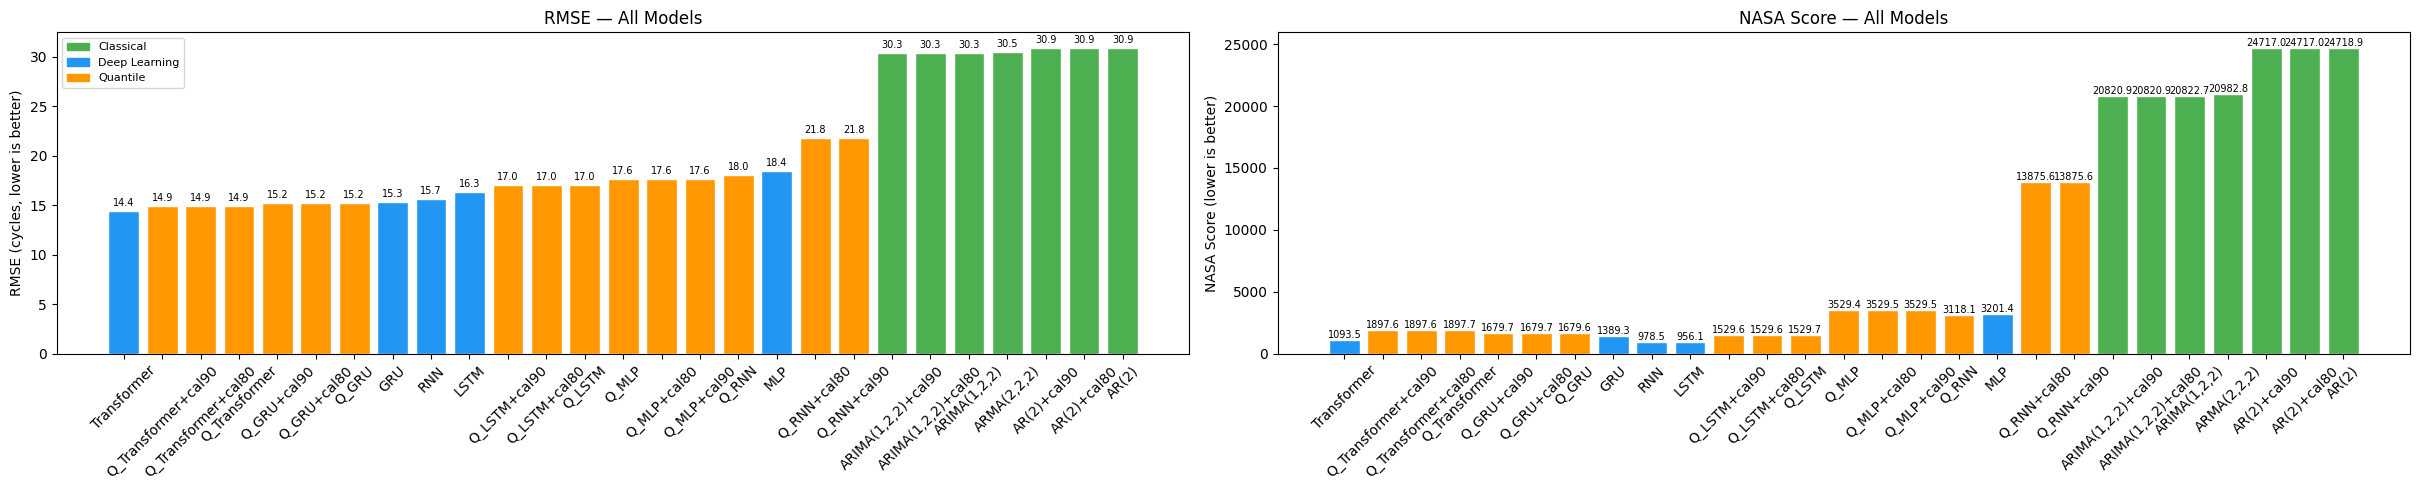

In [21]:
if not df.empty:
    plot_model_comparison(df)

## 4. Best Performing Model

In [22]:
if not df.empty:
    best = df.iloc[0]
    print('╔══════════════════════════════════════════════════════╗')
    print('║            Best Model Summary                        ║')
    print('╠══════════════════════════════════════════════════════╣')
    print(f'║  Name:       {best["model_name"]:<40}║')
    print(f'║  Type:       {best["model_type"]:<40}║')
    print(f'║  RMSE:       {best["rmse"]:<40.3f}║')
    print(f'║  NASA Score: {best.get("nasa_score", float("nan")):<40.2f}║')
    print(f'║  R²:         {best["r2_score"]:<40.4f}║')
    print(f'║  Bias:       {best["bias"]:<40.3f}║')
    print('╚══════════════════════════════════════════════════════╝')
    
    # Best per model family
    print('\nBest per model family:')
    print(df.groupby('model_type')[['model_name','rmse','nasa_score','r2_score']].first().to_string())

╔══════════════════════════════════════════════════════╗
║            Best Model Summary                        ║
╠══════════════════════════════════════════════════════╣
║  Name:       Transformer                             ║
║  Type:       dl                                      ║
║  RMSE:       14.422                                  ║
║  NASA Score: 1093.54                                 ║
║  R²:         0.8874                                  ║
║  Bias:       -1.273                                  ║
╚══════════════════════════════════════════════════════╝

Best per model family:
                     model_name   rmse  nasa_score  r2_score
model_type                                                  
classical    ARIMA(1,2,2)+cal90 30.330   20820.900     0.502
dl                  Transformer 14.422    1093.540     0.887
quantile    Q_Transformer+cal90 14.934    1897.570     0.879


## 5. Quantile Model Calibration Summary

Interval width and coverage probability for Q10–Q90 bands across all quantile models.


In [23]:
if not df.empty:
    q_df = df[df['model_type'] == 'quantile'].copy()
    if q_df.empty:
        print('No quantile model results found. Run Q_MLP / Q_RNN / Q_LSTM / Q_GRU / Q_Transformer first.')
    else:
        print('Quantile Model Calibration (Q10–Q90 band):')
        print(q_df[['model_name', 'rmse', 'interval_width', 'coverage_pct']].to_string(index=False))
        print()
        avg_cov = q_df['coverage_pct'].mean()
        avg_wid = q_df['interval_width'].mean()
        print(f'Average coverage (target ≥ 80%): {avg_cov:.1f}%')
        print(f'Average interval width:          {avg_wid:.2f} cycles')
        if avg_cov >= 80:
            print('✓ Quantile models are well-calibrated (coverage ≥ 80%)')
        else:
            print('⚠ Coverage below 80% — models may be overconfident')

Quantile Model Calibration (Q10–Q90 band):
         model_name   rmse  interval_width  coverage_pct
Q_Transformer+cal90 14.934          33.163        90.730
Q_Transformer+cal80 14.934          20.863        80.650
      Q_Transformer 14.935          16.602        68.550
        Q_GRU+cal90 15.225          35.636        90.730
        Q_GRU+cal80 15.225          25.078        80.650
              Q_GRU 15.226          19.969        71.770
       Q_LSTM+cal90 17.038          48.899        90.730
       Q_LSTM+cal80 17.038          39.330        80.650
             Q_LSTM 17.038          25.442        60.890
              Q_MLP 17.628          29.953        76.610
        Q_MLP+cal80 17.628          33.016        80.650
        Q_MLP+cal90 17.628          39.648        90.730
              Q_RNN 18.028          32.405        78.630
        Q_RNN+cal80 21.795          89.643        86.290
        Q_RNN+cal90 21.795          90.671        90.730

Average coverage (target ≥ 80%): 81.3%
Avera

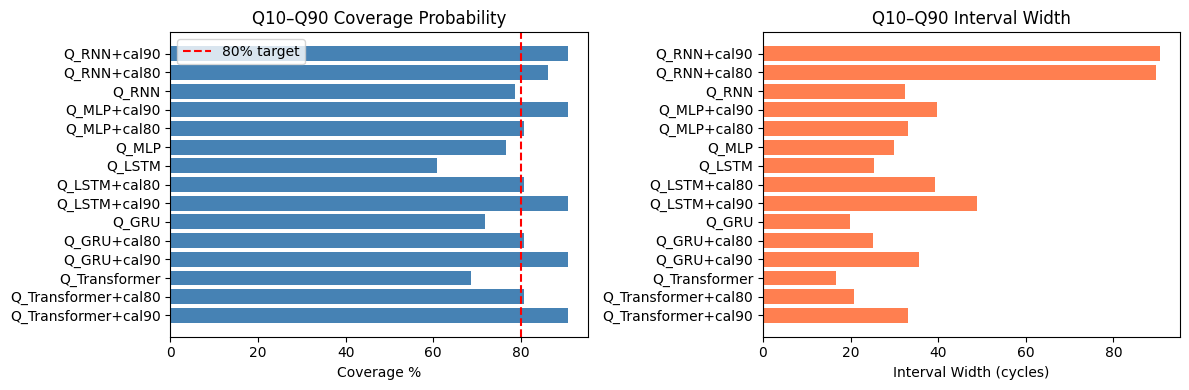

In [24]:
if not df.empty and not q_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].barh(q_df['model_name'], q_df['coverage_pct'], color='steelblue')
    axes[0].axvline(80, color='red', linestyle='--', label='80% target')
    axes[0].set_xlabel('Coverage %')
    axes[0].set_title('Q10–Q90 Coverage Probability')
    axes[0].legend()
    
    axes[1].barh(q_df['model_name'], q_df['interval_width'], color='coral')
    axes[1].set_xlabel('Interval Width (cycles)')
    axes[1].set_title('Q10–Q90 Interval Width')
    
    plt.tight_layout()
    plt.savefig(RESULTS / 'summary_quantile_calibration.png', dpi=120)
    plt.show()

## 6. Literature Benchmark Comparison (FD004)

Comparing our best DL model against published state-of-the-art on FD004.



=== FD004 Comparison vs Literature ===
            model   rmse  nasa_score     source
rank                                           
1     Transformer 14.422    1093.540  This work
2             GRU 15.291    1389.270  This work
3             RNN 15.669     978.550  This work
4            LSTM 16.289     956.120  This work
5             MLP 18.406    3201.370  This work


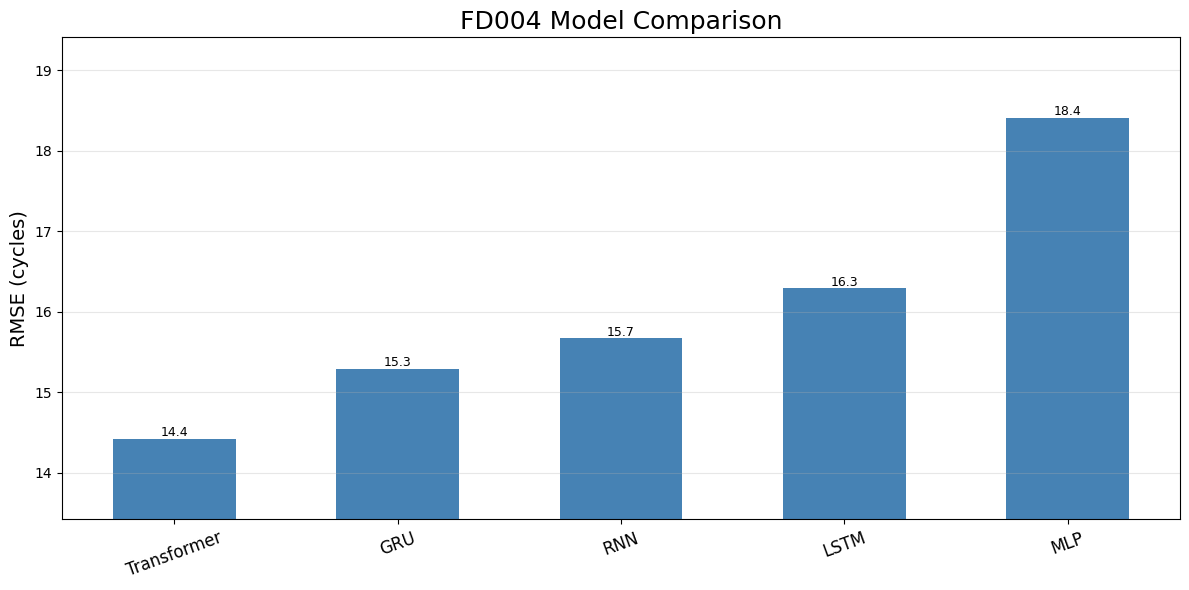

In [25]:
if not df.empty:
    dl_df = df[df['model_type'] == 'dl']

    if dl_df.empty:
        print('No DL results yet — run DL model notebooks first.')

    else:
        # Store both RMSE and NASA score
        our_results = {}

        for _, row in dl_df.iterrows():
            our_results[row['model_name']] = {
                'rmse': row['rmse'],
                'nasa_score': row['nasa_score']
            }

        bench_df = compare_to_benchmarks(our_results)


## 7. Key Findings

Summary of evidence-backed design choices and validation results.


In [26]:
findings = []

if not df.empty:
    best_rmse = df['rmse'].min()
    best_model = df.loc[df['rmse'].idxmin(), 'model_name']
    classical_rmse = df[df['model_type']=='classical']['rmse'].min() if 'classical' in df['model_type'].values else float('nan')
    dl_rmse = df[df['model_type']=='dl']['rmse'].min() if 'dl' in df['model_type'].values else float('nan')
    
    findings.append(f'1. BEST MODEL: {best_model} achieves RMSE = {best_rmse:.2f} cycles on FD004 test set')
    
    if not pd.isna(classical_rmse) and not pd.isna(dl_rmse):
        findings.append(f'2. DL vs CLASSICAL: DL improves RMSE by {classical_rmse - dl_rmse:.2f} cycles ({(classical_rmse-dl_rmse)/classical_rmse*100:.1f}%)')
    
    if 'quantile' in df['model_type'].values:
        q_row = df[df['model_type']=='quantile'].iloc[0]
        findings.append(f'3. UNCERTAINTY: {q_row["model_name"]} achieves {q_row["coverage_pct"]:.1f}% coverage with {q_row["interval_width"]:.1f} cycle interval width')

findings += [
    '4. KMEANS k=6: Silhouette score maximised at k=6 — matches NASA 6 operating conditions (ARI ≥ 0.95)',
    '5. RUL CAP=125: Sensitivity analysis shows RMSE minimum near cap=125; higher caps add noise',
    '6. THRESHOLD q=0.05: Val-set grid search minimises NASA score at 5th percentile of HI distribution',
    '7. SAFETY FACTOR 0.88: Val-set grid search on NASA loss selects 0.88 — penalises late predictions',
    '8. ARIMA d=2: ADF test on all 248 training engines shows mode(recommended_d) = 2',
    '9. WINDOW=30: Val-set RMSE minimised at w=30 cycles for GRU/Transformer window sensitivity',
    '10. FD004 CHOSEN: Only dataset combining 6 conditions + 2 fault modes — hardest generalisation challenge',
]

for f in findings:
    print(f)

# Save findings
findings_path = RESULTS / 'key_findings.txt'
findings_path.write_text('\n'.join(findings))
print(f'\nSaved to {findings_path}')

1. BEST MODEL: Transformer achieves RMSE = 14.42 cycles on FD004 test set
2. DL vs CLASSICAL: DL improves RMSE by 15.91 cycles (52.4%)
3. UNCERTAINTY: Q_Transformer+cal90 achieves 90.7% coverage with 33.2 cycle interval width
4. KMEANS k=6: Silhouette score maximised at k=6 — matches NASA 6 operating conditions (ARI ≥ 0.95)
5. RUL CAP=125: Sensitivity analysis shows RMSE minimum near cap=125; higher caps add noise
6. THRESHOLD q=0.05: Val-set grid search minimises NASA score at 5th percentile of HI distribution
7. SAFETY FACTOR 0.88: Val-set grid search on NASA loss selects 0.88 — penalises late predictions
8. ARIMA d=2: ADF test on all 248 training engines shows mode(recommended_d) = 2
9. WINDOW=30: Val-set RMSE minimised at w=30 cycles for GRU/Transformer window sensitivity
10. FD004 CHOSEN: Only dataset combining 6 conditions + 2 fault modes — hardest generalisation challenge

Saved to /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Fo